Question 1.

In [1]:
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving A3_P1_7b27d5cc-755e-4f78-bab1-6c2373544adc.csv to A3_P1_7b27d5cc-755e-4f78-bab1-6c2373544adc.csv
User uploaded file "A3_P1_7b27d5cc-755e-4f78-bab1-6c2373544adc.csv" with length 60523 bytes


Elbow method

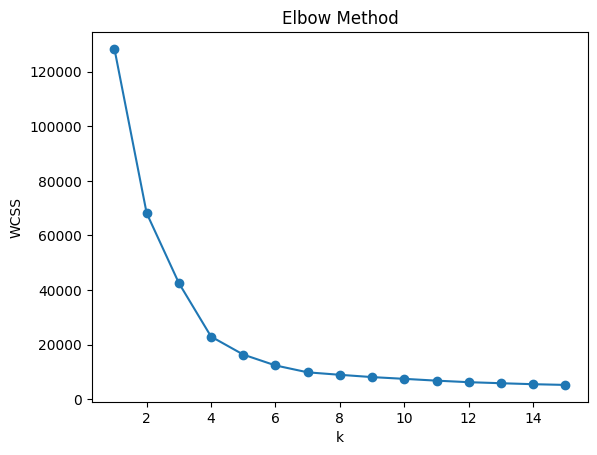

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
X = pd.read_csv('A3_P1_7b27d5cc-755e-4f78-bab1-6c2373544adc.csv').values

wcss = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in range(1,16)]
plt.plot(range(1,16), wcss, marker='o')
plt.xlabel("k"); plt.ylabel("WCSS"); plt.title("Elbow Method"); plt.show()

K-means clustering

Optimal number of cluster =  4 



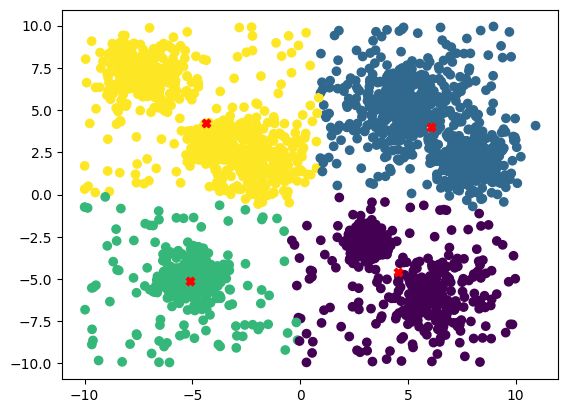

In [3]:
n_clusters=4
print("Optimal number of cluster = ",n_clusters,"\n")
kmeans = KMeans(n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', marker='X')
plt.show()

In [4]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving A3_P2_170cd1d8-a072-4f67-ba36-10f26f772880.csv to A3_P2_170cd1d8-a072-4f67-ba36-10f26f772880.csv
User uploaded file "A3_P2_170cd1d8-a072-4f67-ba36-10f26f772880.csv" with length 379 bytes


Computing single-linkage clustering


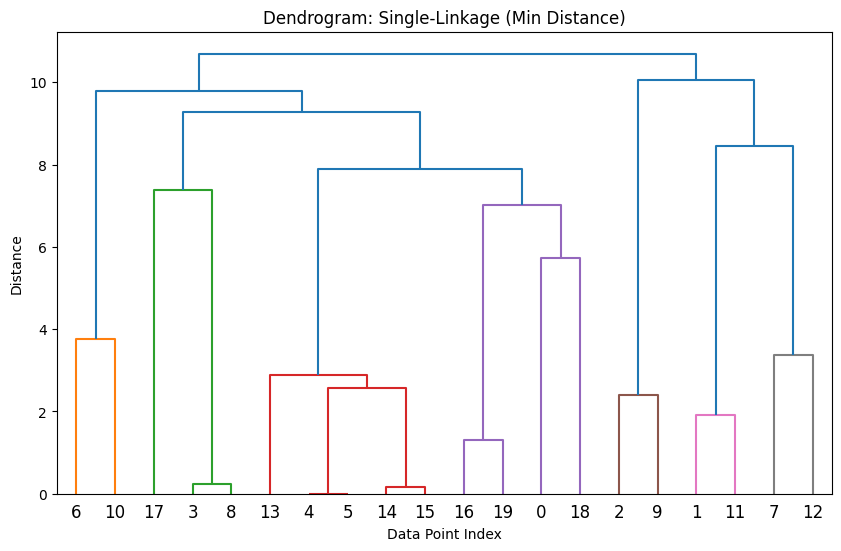

Computing average-linkage clustering


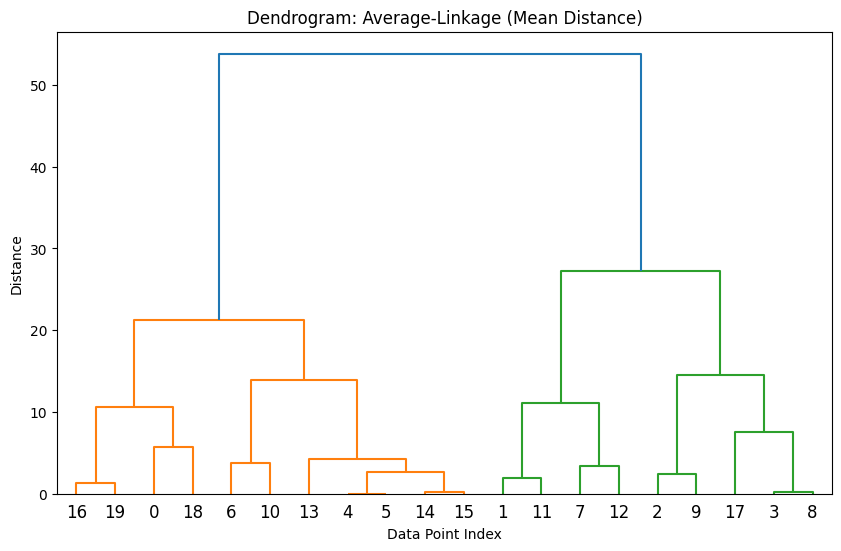

Computing complete-linkage clustering


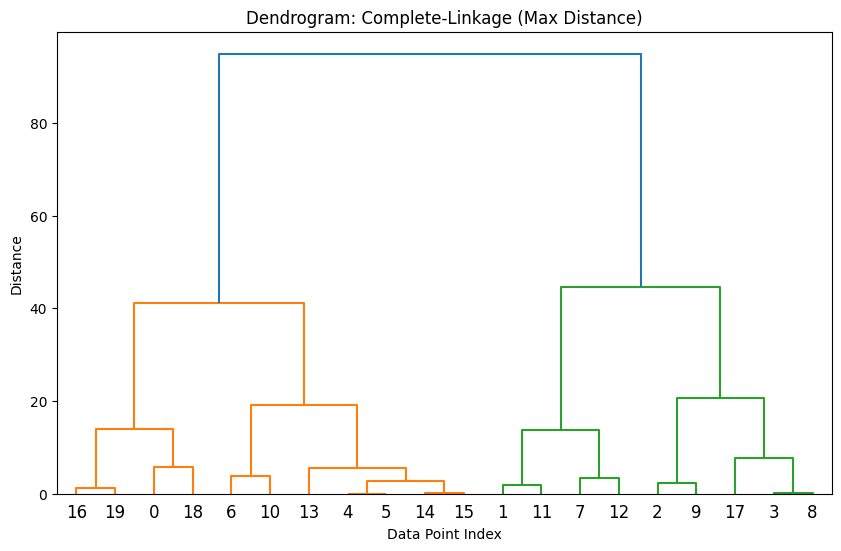

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
df = pd.read_csv('A3_P2_170cd1d8-a072-4f67-ba36-10f26f772880.csv')
X = df.values

def euclidean_distance(u, v):
    return np.sqrt(np.sum((u - v)**2))

def compute_linkage(cluster_A, cluster_B, X, method):
    distances = []
    for i in cluster_A:
        for j in cluster_B:
            distances.append(euclidean_distance(X[i], X[j]))

    if method == 'single':
        return np.min(distances)
    elif method == 'average':
        return np.mean(distances)
    elif method == 'complete':
        return np.max(distances)

def hierarchical_clustering(X, method):
    n = len(X)

    active_clusters = {i: [i] for i in range(n)}

    Z = np.zeros((n - 1, 4))
    next_cluster_id = n

    for step in range(n - 1):
        min_dist = float('inf')
        merge_pair = (-1, -1)

        cluster_ids = list(active_clusters.keys())
        for i in range(len(cluster_ids)):
            for j in range(i + 1, len(cluster_ids)):
                id_A = cluster_ids[i]
                id_B = cluster_ids[j]

                dist = compute_linkage(active_clusters[id_A], active_clusters[id_B], X, method)

                if dist < min_dist:
                    min_dist = dist
                    merge_pair = (id_A, id_B)


        id_A, id_B = merge_pair

        Z[step, 0] = id_A
        Z[step, 1] = id_B
        Z[step, 2] = min_dist
        Z[step, 3] = len(active_clusters[id_A]) + len(active_clusters[id_B])

        active_clusters[next_cluster_id] = active_clusters[id_A] + active_clusters[id_B]

        del active_clusters[id_A]
        del active_clusters[id_B]

        next_cluster_id += 1

    return Z

methods = ['single', 'average', 'complete']
titles = [
    'Single-Linkage (Min Distance)',
    'Average-Linkage (Mean Distance)',
    'Complete-Linkage (Max Distance)'
]

for idx, method in enumerate(methods):
    print(f"Computing {method}-linkage clustering")
    Z = hierarchical_clustering(X, method)

    plt.figure(figsize=(10, 6))
    dendrogram(Z)
    plt.title(f'Dendrogram: {titles[idx]}')
    plt.xlabel('Data Point Index')
    plt.ylabel('Distance')
    plt.show()